# Zonas Gastronómicas de La Paz — Clustering Geoespacial
**Proyecto de Aprendizaje No Supervisado**

**Objetivo:** Descubrir zonas gastronómicas en La Paz, Bolivia usando clustering geoespacial **sin etiquetas previas**. Los datos se recolectan desde SerpAPI (Google Maps), y el modelo descubre por sí solo qué tipos de zonas existen.

**Título**
Descubrimiento de zonas gastronómicas en La Paz mediante clustering geoespacial no supervisado

**Problema que resuelve**
La ciudad de La Paz no tiene un mapa oficial ni sistematizado de sus zonas gastronómicas. Quien quiere saber dónde se concentran los mercados populares, los restaurantes formales o los cafés de moda, depende del boca a boca o de búsquedas manuales en Google Maps. No existe ningún sistema que analice el paisaje gastronómico de la ciudad como un todo y descubra patrones de forma automática.

**Objetivo**
Descubrir y caracterizar zonas gastronómicas emergentes en la ciudad de La Paz aplicando técnicas de aprendizaje no supervisado sobre datos recolectados de Google Maps, sin utilizar etiquetas previas, permitiendo que los patrones geoespaciales y de atributos de los establecimientos determinen por sí solos las agrupaciones.

**De qué trata**
Se recolectan datos de establecimientos de comida en La Paz (restaurantes, cafés, salteñerías, mercados, bares) usando SerpAPI como fuente. Cada lugar aporta su ubicación GPS, tipo, rating, número de reseñas y rango de precio. A partir de esos datos crudos y sin etiquetar, se construye una matriz de features que incluye también la densidad de lugares vecinos en un radio de 500 metros.
Esas features se reducen dimensionalmente con PCA y luego se proyectan con UMAP y t-SNE para visualización. El corazón del proyecto es el algoritmo HDBSCAN, que agrupa los establecimientos según la densidad natural de los datos, sin necesidad de especificar cuántas zonas existen de antemano y marcando como outliers los lugares que no pertenecen a ninguna zona clara.
El resultado es un mapa interactivo de La Paz donde cada punto es un establecimiento coloreado por la zona gastronómica a la que pertenece, junto con el perfil de cada zona: qué tipo de lugares predominan, qué nivel de precios tienen, qué tan populares son y en qué parte de la ciudad se ubican. La fase final convierte ese análisis en una página web explorable.

**Técnicas usadas:**
- Recolección: SerpAPI (Google Maps Local Results)
- Features: coordenadas, densidad vecinal, precio
- Reducción dimensional: PCA → UMAP / t-SNE
- Clustering: KMeans (baseline), DBSCAN, HDBSCAN (principal)
- Métricas: Silhouette Score, Calinski-Harabasz
- Visualización: Folium (mapa interactivo), Matplotlib, Seaborn

---
**Dataset:** No etiquetado. Los grupos emergen del comportamiento espacial y de atributos de los lugares.

---
**Campos extraídos por lugar:**
- `title`: nombre del establecimiento
- `type`: no incluido para que el algoritmo no se deje lleavr por eso 
- `latitude` / `longitude`: coordenadas GPS
- `rating`: calificación promedio (1-5)
- `reviews`: número de reseñas
- `price`: rango de precio ($, $$, $$$)
- `address`: dirección completa

## Contexto del Proyecto

**Problema:** La Paz no tiene un mapa sistematizado de sus zonas gastronómicas.
Quien quiere saber dónde se concentran los mercados populares, restaurantes formales
o cafés de moda depende del boca a boca o búsquedas manuales en Google Maps.

**Objetivo:** Descubrir y caracterizar zonas gastronómicas en La Paz aplicando
aprendizaje **no supervisado** sobre datos de Google Maps (SerpAPI), **sin usar
etiquetas previas**. Los patrones emergen solos.

**Corrección importante respecto a una versión anterior:**
> En la primera versión se incluía el one-hot del tipo de establecimiento
> (`tipo_restaurante`, `tipo_cafe`, etc.) como feature. Eso hacía que el modelo
> simplemente agrupara por tipo — no descubría nada nuevo.
> En esta versión **solo se usan features geoespaciales y numéricas**:
> coordenadas, rating, popularidad, precio y densidad vecinal.
> El tipo de establecimiento queda como variable de *interpretación posterior*.


## 0. Instalación de dependencias

In [1]:
# Instalar todas las librerías necesarias
# Ejecutar solo una vez al inicio del proyecto
!pip install requests pandas numpy scikit-learn umap-learn hdbscan folium matplotlib seaborn tqdm serpapi -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuración e imports

Importamos todas las librerías y configuramos la API key de SerpAPI.


In [6]:
# --- Librerías estándar ---
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

# --- Manejo de datos ---
import numpy as np
import pandas as pd

# --- HTTP / API ---
import requests

# --- Visualización ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap

# --- Preprocesamiento ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# --- Clustering ---
from sklearn.cluster import KMeans, DBSCAN
import hdbscan

# --- Métricas ---
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# --- Reducción dimensional avanzada ---
import umap
from sklearn.manifold import TSNE

# --- Progreso ---
from tqdm import tqdm

# ============================================================
# CONFIGURACIÓN
# ============================================================
# Reemplaza con tu API key de https://serpapi.com/
SERPAPI_KEY = "TU_SERPAPI"

# Bounding box de La Paz, Bolivia (ciudad, no departamento)
LA_PAZ_CENTER = {"lat": -16.5000, "lon": -68.1500}

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta de colores para los clusters
CLUSTER_COLORS = [
    '#E63946', '#2A9D8F', '#F4A261', '#457B9D',
    '#6A0572', '#3D405B', '#81B29A', '#F2CC8F',
    '#A8DADC', '#E9C46A'
]

print("✓ Librerías importadas correctamente")
print(f"✓ Centro de La Paz: {LA_PAZ_CENTER}")

✓ Librerías importadas correctamente
✓ Centro de La Paz: {'lat': -16.5, 'lon': -68.15}


## 2. Recolección de datos con SerpAPI

Usamos el endpoint `google_maps` de SerpAPI para buscar establecimientos gastronómicos en La Paz.
Realizamos múltiples queries con diferentes términos para maximizar la cobertura.

**Endpoint usado:** `https://serpapi.com/search?engine=google_maps`

**Campos extraídos por lugar:**
- `title`: nombre del establecimiento
- `type`: categoría (restaurant, cafe, etc.)
- `latitude` / `longitude`: coordenadas GPS
- `rating`: calificación promedio (1-5)
- `reviews`: número de reseñas
- `price`: rango de precio ($, $$, $$$)
- `address`: dirección completa

In [3]:
def buscar_lugares_serpapi(query: str, api_key: str, lat: float, lon: float,
                            zoom: int = 14, n_paginas: int = 3) -> list:
    """
    Busca lugares en Google Maps via SerpAPI.

    Parámetros:
        query     : término de búsqueda (ej. 'restaurantes La Paz Bolivia')
        api_key   : tu API key de SerpAPI
        lat, lon  : coordenadas del centro de búsqueda
        zoom      : nivel de zoom del mapa (14 = barrio, 12 = ciudad)
        n_paginas : cuántas páginas de resultados traer

    Retorna:
        Lista de dicts con los datos de cada lugar
    """
    resultados = []
    start = 0

    for pagina in range(n_paginas):
        params = {
            "engine": "google_maps",
            "q": query,
            "ll": f"@{lat},{lon},{zoom}z",  # coordenadas y zoom
            "type": "search",
            "api_key": api_key,
            "start": start,
            "hl": "es",   # idioma español
            "gl": "bo",   # país Bolivia
        }

        try:
            resp = requests.get("https://serpapi.com/search", params=params, timeout=30)
            resp.raise_for_status()
            data = resp.json()

            lugares = data.get("local_results", [])
            if not lugares:
                break  # sin más resultados

            for lugar in lugares:
                # Extraer GPS desde el campo 'gps_coordinates' o 'position'
                gps = lugar.get("gps_coordinates", {})
                lat_l = gps.get("latitude")
                lon_l = gps.get("longitude")

                if lat_l is None or lon_l is None:
                    continue  # sin coordenadas → ignorar

                resultados.append({
                    "nombre":       lugar.get("title", ""),
                    "tipo":         lugar.get("type", "desconocido"),
                    "lat":          float(lat_l),
                    "lon":          float(lon_l),
                    "rating":       lugar.get("rating", np.nan),
                    "n_resenas":    lugar.get("reviews", 0),
                    "precio":       lugar.get("price", ""),
                    "direccion":    lugar.get("address", ""),
                    "query_origen": query,   # rastreabilidad
                })

            start += 20  # siguiente página (20 resultados por página)
            time.sleep(1.5)  # pausa para no saturar la API

        except Exception as e:
            print(f"  ⚠ Error en página {pagina+1} de '{query}': {e}")
            break

    return resultados


print("✓ Función de scraping definida")

✓ Función de scraping definida


In [4]:
# ============================================================
# QUERIES DE BÚSQUEDA
# Variamos los términos para cubrir distintos tipos de lugares
# y distintas zonas de La Paz
# ============================================================
QUERIES = [
    "restaurantes La Paz Bolivia",
    "cafeterías La Paz Bolivia",
    "comida rápida La Paz Bolivia",
    "salteñerías La Paz Bolivia",
    "mercado comida La Paz Bolivia",
    "pizzería La Paz Bolivia",
    "bar La Paz Bolivia",
    "heladerías La Paz Bolivia",
    "anticuchería La Paz Bolivia",
    "desayuno La Paz Bolivia",
    "almuerzo económico La Paz Bolivia",
    "cena La Paz Bolivia",
]

# ============================================================
# RECOLECCIÓN
# ============================================================
todos_los_lugares = []

for query in tqdm(QUERIES, desc="Scrapeando SerpAPI"):
    lugares = buscar_lugares_serpapi(
        query=query,
        api_key=SERPAPI_KEY,
        lat=LA_PAZ_CENTER["lat"],
        lon=LA_PAZ_CENTER["lon"],
        zoom=14,
        n_paginas=3
    )
    todos_los_lugares.extend(lugares)
    print(f"  '{query}': {len(lugares)} lugares encontrados")

# Crear DataFrame crudo
df_raw = pd.DataFrame(todos_los_lugares)
print(f"\n✓ Total recolectado (con duplicados): {len(df_raw)} registros")
df_raw.head()

Scrapeando SerpAPI:   8%|▊         | 1/12 [00:10<01:51, 10.10s/it]

  'restaurantes La Paz Bolivia': 60 lugares encontrados


Scrapeando SerpAPI:  17%|█▋        | 2/12 [00:26<02:20, 14.07s/it]

  'cafeterías La Paz Bolivia': 60 lugares encontrados


Scrapeando SerpAPI:  25%|██▌       | 3/12 [00:37<01:50, 12.27s/it]

...

Scrapeando SerpAPI:  92%|█████████▏| 11/12 [02:09<00:12, 12.17s/it]

  'almuerzo económico La Paz Bolivia': 60 lugares encontrados


Scrapeando SerpAPI: 100%|██████████| 12/12 [02:26<00:00, 12.18s/it]

  'cena La Paz Bolivia': 60 lugares encontrados

✓ Total recolectado (con duplicados): 626 registros


,nombre,tipo,lat,lon,rating,n_resenas,precio,direccion,query_origen
0,Oliva Restaurant - Cocina Abierta,Restaurante,-16.497125,-68.138512,4.6,903,Bs 40-100,"Linares, La Paz",restaurantes La Paz Bolivia
1,YATI Restaurant café bar,Restaurante,-16.498520,-68.137158,4.6,727,Bs 40-80,"+591, La Paz",restaurantes La Paz Bolivia
2,Popular Cocina Boliviana,Restaurante,-16.496020,-68.138279,4.6,1470,Bs 80-100,"Murillo 826, La Paz",restaurantes La Paz Bolivia
3,Gustu,Restaurante de cocina sudamericana,-16.544707,-68.086413,4.5,1887,Más de Bs 200,"Calle 10 de Calacoto, casi, La Paz",restaurantes La Paz Bolivia
4,Café Restaurante Banais,Restaurante,-16.496792,-68.137258,4.5,853,Bs 40-120,"Sagarnaga 161, La Paz",restaurantes La Paz Bolivia


In [5]:
# ============================================================
# GUARDAR DATASET RAW
# Guardamos antes de limpiar para tener el original
# ============================================================
df_raw.to_csv("dataset_lapaz_raw.csv", index=False, encoding="utf-8")
print(f"✓ Dataset raw guardado: dataset_lapaz_raw.csv ({len(df_raw)} filas)")

# ============================================================
# DEDUPLICACIÓN
# Un mismo lugar puede aparecer en múltiples queries.
# Usamos lat+lon redondeados a 5 decimales (~1m de precisión)
# ============================================================
df_raw["lat_r"] = df_raw["lat"].round(5)
df_raw["lon_r"] = df_raw["lon"].round(5)

df = df_raw.drop_duplicates(subset=["lat_r", "lon_r"]).copy()
df = df.drop(columns=["lat_r", "lon_r"])
df = df.reset_index(drop=True)

print(f"✓ Después de deduplicar: {len(df)} lugares únicos")
print(f"  Duplicados removidos: {len(df_raw) - len(df)}")
df.info()

✓ Dataset raw guardado: dataset_lapaz_raw.csv (626 filas)
✓ Después de deduplicar: 427 lugares únicos
  Duplicados removidos: 199
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nombre        427 non-null    object 
 1   tipo          427 non-null    object 
 2   lat           427 non-null    float64
 3   lon           427 non-null    float64
 4   rating        422 non-null    float64
 5   n_resenas     427 non-null    int64  
 6   precio        427 non-null    object 
 7   direccion     427 non-null    object 
 8   query_origen  427 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 30.2+ KB


## 3. Exploración de datos (EDA)

Antes de cualquier modelo, entendemos qué tenemos: distribución geográfica, tipos de lugares, valores faltantes y distribuciones de variables numéricas.

In [2]:
import pandas as pd
import numpy as np

# cargar dataset
df = pd.read_csv("dataset_lapaz_raw.csv")

print(df.head())
print(df.shape)

                              nombre                                tipo  \
0  Oliva Restaurant - Cocina Abierta                         Restaurante   
1           YATI Restaurant café bar                         Restaurante   
2           Popular Cocina Boliviana                         Restaurante   
3                              Gustu  Restaurante de cocina sudamericana   
4            Café Restaurante Banais                         Restaurante   

         lat        lon  rating  n_resenas         precio  \
0 -16.497125 -68.138512     4.6        903      Bs 40-100   
1 -16.498520 -68.137158     4.6        727       Bs 40-80   
2 -16.496020 -68.138279     4.6       1470      Bs 80-100   
3 -16.544707 -68.086413     4.5       1887  Más de Bs 200   
4 -16.496792 -68.137258     4.5        853      Bs 40-120   

                            direccion                 query_origen  
0                     Linares, La Paz  restaurantes La Paz Bolivia  
1                        +591, La Paz 

In [3]:
print("=" * 55)
print("RESUMEN DEL DATASET")
print("=" * 55)
print(f"Total de lugares: {len(df)}")
print(f"\nVariables:")
print(df.dtypes)
print(f"\nValores faltantes:")
print(df.isnull().sum())
print(f"\nEstadísticas numéricas:")
df[["lat","lon","rating","n_resenas"]].describe().round(3)

RESUMEN DEL DATASET
Total de lugares: 626

Variables:
nombre           object
tipo             object
lat             float64
lon             float64
rating          float64
n_resenas         int64
precio           object
direccion        object
query_origen     object
dtype: object

Valores faltantes:
nombre            0
tipo              0
lat               0
lon               0
rating            5
n_resenas         0
precio          152
direccion         0
query_origen      0
dtype: int64

Estadísticas numéricas:


,lat,lon,rating,n_resenas
count,626.000,626.000,621.000,626.000
mean,-16.514,-68.116,4.264,553.141
std,0.019,0.025,0.417,916.515
min,-16.546,-68.185,1.300,0.000
25%,-16.535,-68.137,4.000,85.500
50%,-16.509,-68.127,4.300,279.500
75%,-16.498,-68.086,4.500,715.250
max,-16.475,-68.066,5.000,11443.000


In [4]:
import re
import numpy as np

# ============================================================
# LIMPIEZA PROFESIONAL DE PRECIOS
# ============================================================

def extraer_precio(texto):

    # faltantes
    if pd.isna(texto):
        return np.nan, np.nan, np.nan

    texto = str(texto)

    # eliminar unicode raro
    texto = texto.replace("\xa0", " ").strip()

    # símbolos $
    if texto == "$":
        return 1, 20, 10

    elif texto == "$$":
        return 20, 80, 50

    elif texto == "$$$":
        return 80, 200, 140

    # Más de Bs 200
    if "Más de" in texto:
        nums = re.findall(r"\d+", texto)

        if nums:
            minimo = int(nums[0])
            maximo = minimo + 100
            promedio = (minimo + maximo) / 2
            return minimo, maximo, promedio

    # Rangos normales Bs 40-100
    nums = re.findall(r"\d+", texto)

    if len(nums) >= 2:
        minimo = int(nums[0])
        maximo = int(nums[1])
        promedio = (minimo + maximo) / 2
        return minimo, maximo, promedio

    return np.nan, np.nan, np.nan


# ============================================================
# APLICAR
# ============================================================

df[["precio_min", "precio_max", "precio_prom"]] = (
    df["precio"]
    .apply(extraer_precio)
    .apply(pd.Series)
)

# ============================================================
# VERIFICAR
# ============================================================

print(df[[
    "precio",
    "precio_min",
    "precio_max",
    "precio_prom"
]].head(20))

           precio  precio_min  precio_max  precio_prom
0       Bs 40-100        40.0       100.0         70.0
1        Bs 40-80        40.0        80.0         60.0
2       Bs 80-100        80.0       100.0         90.0
3   Más de Bs 200       200.0       300.0        250.0
4       Bs 40-120        40.0       120.0         80.0
5      Bs 100-200       100.0       200.0        150.0
6       Bs 80-100        80.0       100.0         90.0
7        Bs 20-40        20.0        40.0         30.0
8       Bs 80-180        80.0       180.0        130.0
9        Bs 20-40        20.0        40.0         30.0
10      Bs 60-160        60.0       160.0        110.0
11      Bs 80-140        80.0       140.0        110.0
12       Bs 60-80        60.0        80.0         70.0
13       Bs 60-80        60.0        80.0         70.0
14      Bs 40-100        40.0       100.0         70.0
15      Bs 40-140        40.0       140.0         90.0
16      Bs 60-140        60.0       140.0        100.0
17      Bs

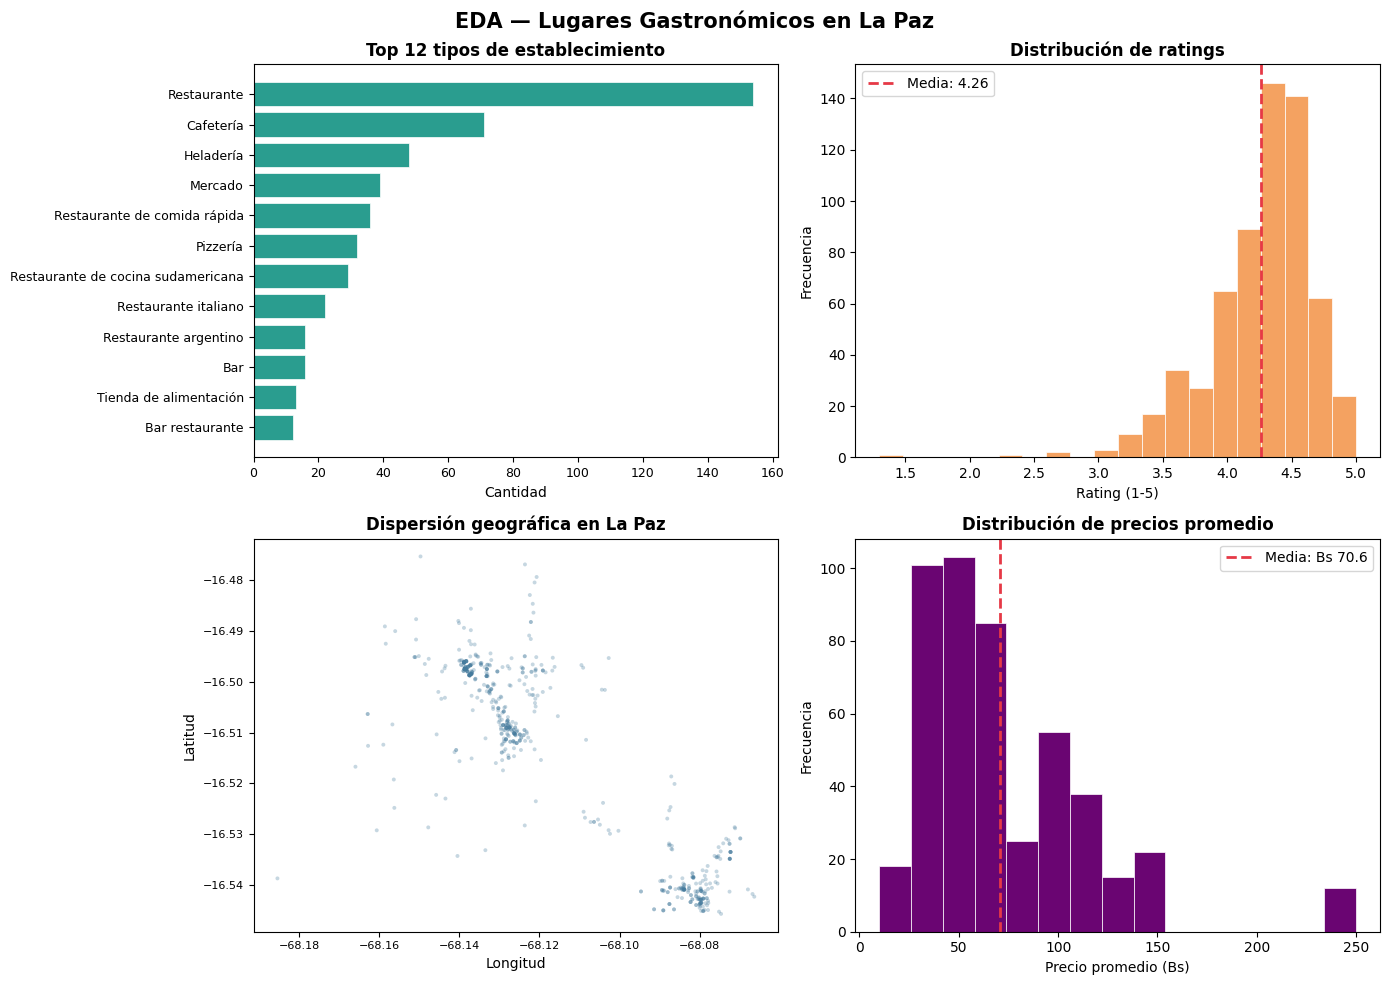

✓ Gráfico guardado: eda_overview.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Lugares Gastronómicos en La Paz", fontsize=15, fontweight="bold")

# --- 1. Top tipos de lugares ---
top_tipos = df["tipo"].value_counts().head(12)
axes[0,0].barh(top_tipos.index[::-1], top_tipos.values[::-1],
               color="#2A9D8F", edgecolor="white", linewidth=0.5)
axes[0,0].set_title("Top 12 tipos de establecimiento", fontweight="bold")
axes[0,0].set_xlabel("Cantidad")
axes[0,0].tick_params(labelsize=9)

# --- 2. Distribución de ratings ---
ratings_validos = df["rating"].dropna()
axes[0,1].hist(ratings_validos, bins=20, color="#F4A261",
               edgecolor="white", linewidth=0.5)
axes[0,1].axvline(ratings_validos.mean(), color="#E63946",
                  linestyle="--", linewidth=2,
                  label=f"Media: {ratings_validos.mean():.2f}")
axes[0,1].set_title("Distribución de ratings", fontweight="bold")
axes[0,1].set_xlabel("Rating (1-5)")
axes[0,1].set_ylabel("Frecuencia")
axes[0,1].legend()

# --- 3. Dispersión geográfica ---
axes[1,0].scatter(df["lon"], df["lat"], alpha=0.3, s=8,
                  color="#457B9D", edgecolors="none")
axes[1,0].set_title("Dispersión geográfica en La Paz", fontweight="bold")
axes[1,0].set_xlabel("Longitud")
axes[1,0].set_ylabel("Latitud")
axes[1,0].tick_params(labelsize=8)

# --- 4. Distribución de precios ---
# --- 4. Distribución de precios promedio ---
precios_validos = df["precio_prom"].dropna()

axes[1,1].hist(
    precios_validos,
    bins=15,
    color="#6A0572",
    edgecolor="white",
    linewidth=0.5
)

axes[1,1].axvline(
    precios_validos.mean(),
    color="#E63946",
    linestyle="--",
    linewidth=2,
    label=f"Media: Bs {precios_validos.mean():.1f}"
)

axes[1,1].set_title("Distribución de precios promedio", fontweight="bold")
axes[1,1].set_xlabel("Precio promedio (Bs)")
axes[1,1].set_ylabel("Frecuencia")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("img/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráfico guardado: eda_overview.png")

In [8]:
# Mapa base de distribución geográfica (sin clusters aún)
mapa_base = folium.Map(
    location=[LA_PAZ_CENTER["lat"], LA_PAZ_CENTER["lon"]],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Heatmap de densidad
heat_data = df[["lat", "lon"]].dropna().values.tolist()
HeatMap(heat_data, radius=12, blur=15, min_opacity=0.4).add_to(mapa_base)

mapa_base.save("mapa_base_lapaz.html")
print("✓ Mapa base guardado: mapa_base_lapaz.html")
mapa_base  # mostrar en notebook

✓ Mapa base guardado: mapa_base_lapaz.html


## 4. Feature Engineering

Construimos la matriz de features que usarán los algoritmos de clustering.

**Decisión de diseño clave — sin one-hot de tipo:**
Incluir el tipo de establecimiento como feature haría que el modelo agrupe
trivialmente por categoría (todos los cafés juntos, todos los bares juntos),
lo que equivale a replicar una etiqueta que ya existía. Queremos que el modelo
descubra patrones basados en **comportamiento geoespacial y atributos numéricos**.
El tipo se usa solo al final para *interpretar* los clusters.

| Feature | Tipo | Descripción |
|---|---|---|
| `lat`, `lon` | numérica | posición GPS — base geoespacial |
| `rating_norm` | numérica (0-1) | rating normalizado |
| `log_resenas` | numérica | log(n_resenas+1) — popularidad sin sesgo |
| `precio_num` | numérica (0-3) | precio ordinal |
| `densidad_500m` | numérica | lugares similares en radio 500m |


In [9]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np
import pandas as pd

df_feat = df.copy()

# ── 1. Imputar valores faltantes ──────────────────────────
media_rating = df_feat["rating"].median()
df_feat["rating"] = df_feat["rating"].fillna(media_rating)
df_feat["n_resenas"] = df_feat["n_resenas"].fillna(0)
df_feat["precio_prom"] = df_feat["precio_prom"].fillna(df_feat["precio_prom"].median())

# ── 2. Transformación de rating (0-1) ─────────────────────
df_feat["rating_norm"] = (df_feat["rating"] - 1) / 4

# ── 3. Log de reseñas (reduce skewness de lugares muy populares) ──
df_feat["log_resenas"] = np.log1p(df_feat["n_resenas"])

# ── 4. Precio numérico ────────────────────────────────────
df_feat["precio_num"] = df_feat["precio_prom"]

# ── 5. Densidad vecinal (radio 500m via Haversine) ─────────
coords_rad = np.radians(df_feat[["lat", "lon"]].values)
dist_matrix = haversine_distances(coords_rad) * 6371000  # metros
RADIO_M = 500
df_feat["densidad_500m"] = (dist_matrix < RADIO_M).sum(axis=1) - 1
print(f"✓ Densidad media a 500m: {df_feat['densidad_500m'].mean():.1f} lugares")

# ── 6. Categorizar tipo (solo para interpretación posterior) ──
df_feat["tipo_clean"] = df_feat["tipo"].astype(str).str.lower().str.strip()

def categorizar_tipo(t):
    t = str(t).lower()
    if any(k in t for k in ["restaurant", "restaurante", "comida", "cocina",
                              "pizza", "hambur", "vegano", "peruano", "italiano"]):
        return "restaurante"
    elif any(k in t for k in ["cafe", "cafetería", "coffee"]):
        return "cafe"
    elif any(k in t for k in ["fast", "rápida", "burger"]):
        return "comida_rapida"
    elif any(k in t for k in ["bar", "pub", "cervecería"]):
        return "bar"
    elif any(k in t for k in ["mercado", "market"]):
        return "mercado"
    elif any(k in t for k in ["helad"]):
        return "heladeria"
    else:
        return "otro"

df_feat["tipo_cat"] = df_feat["tipo_clean"].apply(categorizar_tipo)
print("✓ Distribución de categorías (referencia, NO entra al modelo):")
print(df_feat["tipo_cat"].value_counts())

# ── 7. Selección final de features — SIN one-hot de tipo ──────────────────
# CORRECCIÓN CLAVE:
# NO incluimos tipo_*, porque haría que el modelo agrupe trivialmente por
# categoría de lugar, replicando una etiqueta que ya existe en los datos.
# El tipo se usará solo para INTERPRETAR los clusters después.

#feature_cols = [
    #"lat",
    #"lon",
    #"rating_norm",
    #"log_resenas",
    #"precio_num",
    #"densidad_500m",
#]
# ── Transformación logarítmica del precio ─────────────────
df_feat["precio_log"] = np.log1p(df_feat["precio_num"])
feature_cols = [
    "lat",
    "lon",
    "densidad_500m",
    "rating_norm",
    "log_resenas",
    "precio_log"
]
X_raw = df_feat[feature_cols].astype(float).values
print(f"\n✓ Matriz de features: {X_raw.shape} (lugares × features)")
print(f"  Features: {feature_cols}")
print("\n→ El tipo de establecimiento queda fuera del modelo.")
print("  Se usará solo al final para describir qué descubrió HDBSCAN.")


✓ Densidad media a 500m: 70.1 lugares
✓ Distribución de categorías (referencia, NO entra al modelo):
tipo_cat
restaurante    353
otro            74
cafe            71
heladeria       48
mercado         46
bar             34
Name: count, dtype: int64

✓ Matriz de features: (626, 6) (lugares × features)
  Features: ['lat', 'lon', 'densidad_500m', 'rating_norm', 'log_resenas', 'precio_log']

→ El tipo de establecimiento queda fuera del modelo.
  Se usará solo al final para describir qué descubrió HDBSCAN.


In [11]:
# ── Normalización (StandardScaler) ────────────────────────
# Las coordenadas lat/lon tienen escala diferente a las demás features.
# StandardScaler lleva todo a media=0, std=1.
# StandardScaler normaliza todas las variables
# a media 0 y desviación estándar 1.
# Esto evita que variables con escalas grandes
# dominen el clustering.
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("✓ Features escaladas")
print(f"  Media por feature (debe ser ~0): {X.mean(axis=0).round(3)}")
print(f"  Std por feature (debe ser ~1):  {X.std(axis=0).round(3)}")

# Guardar dataset de features para reproducibilidad
df_features = pd.DataFrame(X, columns=feature_cols)
df_features["nombre"] = df_feat["nombre"].values
df_features.to_csv("dataset_lapaz_features.csv", index=False)
print("✓ Features guardadas: dataset_lapaz_features.csv")

✓ Features escaladas
  Media por feature (debe ser ~0): [ 0. -0. -0.  0.  0.  0.]
  Std por feature (debe ser ~1):  [1. 1. 1. 1. 1. 1.]
✓ Features guardadas: dataset_lapaz_features.csv


## 5. Reducción Dimensional

Aplicamos dos pasos:
1. **PCA** — reducimos a 5 componentes para eliminar ruido
2. **UMAP** y **t-SNE** — proyectamos a 2D para visualización

La reducción dimensional no elimina las coordenadas geoespaciales del clustering, solo ayuda a la visualización y al modelo a manejar mejor la alta dimensionalidad del one-hot encoding.

Componentes para 90% de varianza explicada: 5


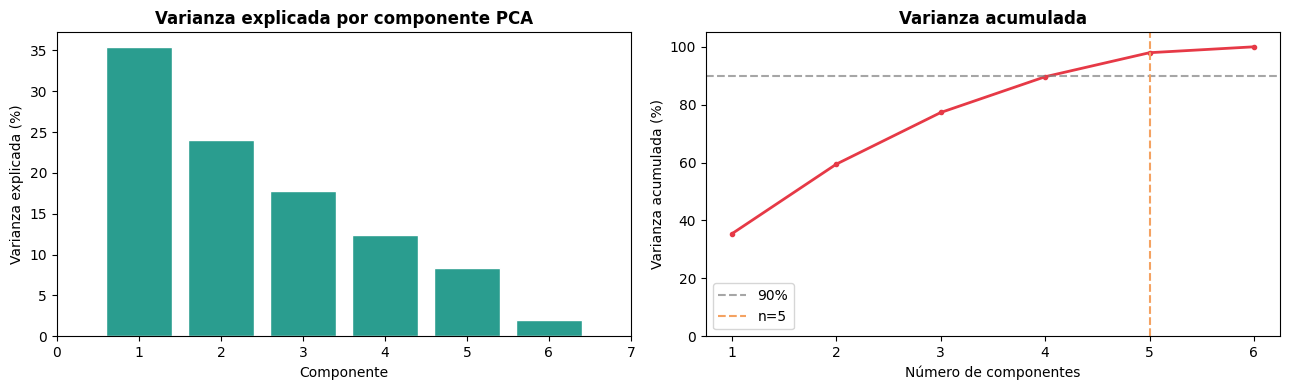

✓ PCA aplicado → (626, 5)


In [12]:
# ── PCA — varianza explicada ───────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_90 = np.argmax(varianza_acum >= 0.90) + 1
print(f"Componentes para 90% de varianza explicada: {n_componentes_90}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Varianza por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100,
            color="#2A9D8F", edgecolor="white")
axes[0].set_title("Varianza explicada por componente PCA", fontweight="bold")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_xlim(0, min(20, X.shape[1]) + 1)

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acum)+1), varianza_acum * 100,
             color="#E63946", linewidth=2, marker="o", markersize=3)
axes[1].axhline(90, color="gray", linestyle="--", alpha=0.7, label="90%")
axes[1].axvline(n_componentes_90, color="#F4A261", linestyle="--",
                label=f"n={n_componentes_90}")
axes[1].set_title("Varianza acumulada", fontweight="bold")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig("pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

# Reducir a n componentes que explican 90%
pca = PCA(n_components=n_componentes_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
print(f"✓ PCA aplicado → {X_pca.shape}")

In [13]:
# ── UMAP — proyección 2D ───────────────────────────────────
print("Calculando UMAP (puede tardar ~1 min)...")

reducer_umap = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    random_state=RANDOM_STATE,
    metric="euclidean"
)

X_umap = reducer_umap.fit_transform(X_pca)

print(f"✓ UMAP: {X_umap.shape}")

# ── t-SNE — para comparación ───────────────────────────────
print("Calculando t-SNE (puede tardar ~2 min)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_pca)

print(f"✓ t-SNE: {X_tsne.shape}")

# ── Guardar embeddings ─────────────────────────────────────
df_feat["umap_1"] = X_umap[:, 0]
df_feat["umap_2"] = X_umap[:, 1]

df_feat["tsne_1"] = X_tsne[:, 0]
df_feat["tsne_2"] = X_tsne[:, 1]

print("✓ Embeddings agregados a df_feat")

Calculando UMAP (puede tardar ~1 min)...
✓ UMAP: (626, 2)
Calculando t-SNE (puede tardar ~2 min)...
✓ t-SNE: (626, 2)
✓ Embeddings agregados a df_feat


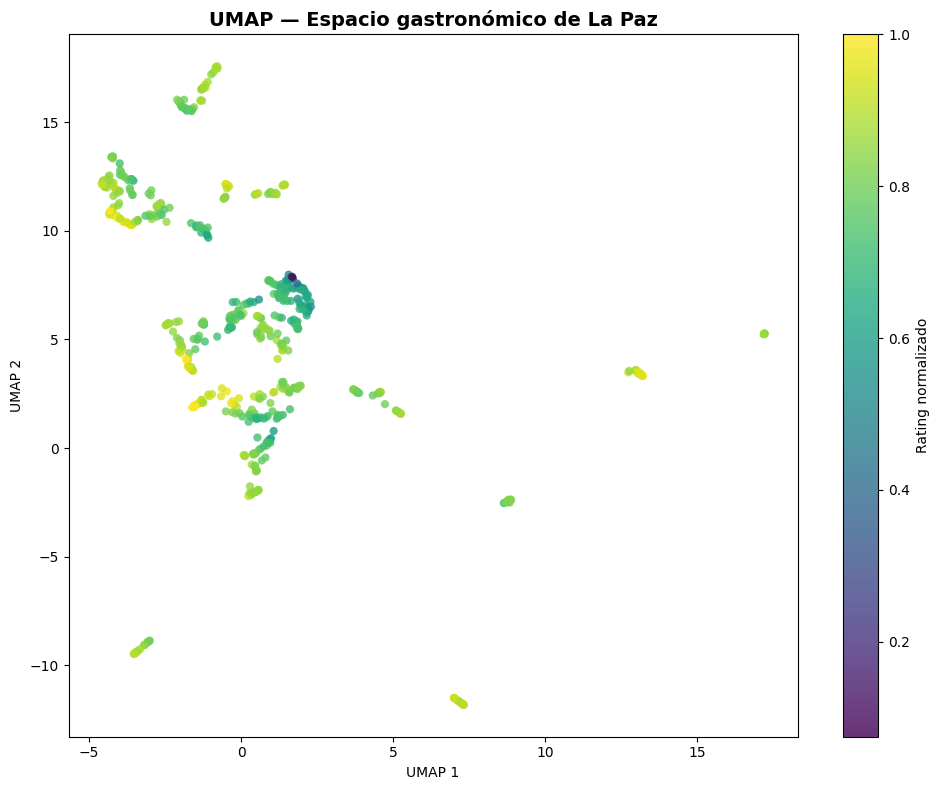

✓ Gráfico UMAP guardado: umap_visualizacion.png


In [14]:
# ── Visualización UMAP ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    df_feat["umap_1"],
    df_feat["umap_2"],
    c=df_feat["rating_norm"],   # colorear por rating
    cmap="viridis",
    s=35,
    alpha=0.8,
    edgecolors="none"
)

ax.set_title(
    "UMAP — Espacio gastronómico de La Paz",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# Barra de color
cbar = plt.colorbar(scatter)
cbar.set_label("Rating normalizado")

plt.tight_layout()

plt.savefig(
    "umap_visualizacion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✓ Gráfico UMAP guardado: umap_visualizacion.png")

In [ ]:
print(df_feat.columns.tolist())

['nombre', 'tipo', 'lat', 'lon', 'rating', 'n_resenas', 'precio', 'direccion', 'query_origen', 'precio_min', 'precio_max', 'precio_prom', 'rating_norm', 'log_resenas', 'precio_num', 'densidad_500m', 'tipo_clean', 'tipo_cat', 'precio_log', 'umap_1', 'umap_2', 'tsne_1', 'tsne_2']


## 6. Clustering

Aplicamos tres algoritmos:
- **KMeans** — baseline clásico, asume clusters esféricos. Usamos el método del codo para k óptimo.
- **DBSCAN** — basado en densidad, no necesita especificar k, detecta outliers.
- **HDBSCAN** — versión jerárquica de DBSCAN, más robusto para densidades variables (ciudades reales).

Evaluando KMeans para k=2..12...


100%|██████████| 11/11 [00:00<00:00, 16.51it/s]


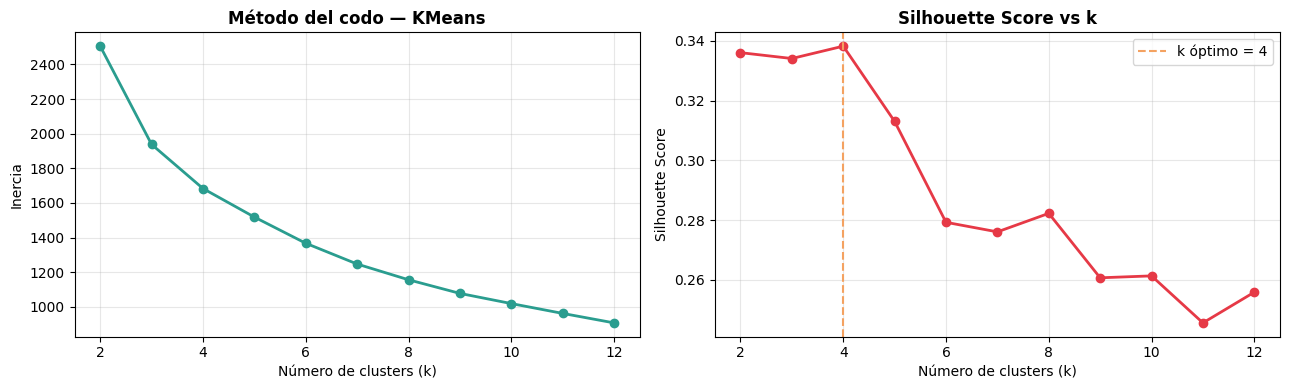

✓ k óptimo por Silhouette: 4


In [15]:
# ── 6.1 KMeans — método del codo ──────────────────────────
# Probamos k de 2 a 12 y calculamos inercia y Silhouette
inertias = []
silhouettes_km = []
K_RANGE = range(2, 13)

print("Evaluando KMeans para k=2..12...")
for k in tqdm(K_RANGE):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_pca, etiquetas, sample_size=min(2000, len(X_pca))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva del codo
axes[0].plot(list(K_RANGE), inertias, "o-", color="#2A9D8F", linewidth=2, markersize=6)
axes[0].set_title("Método del codo — KMeans", fontweight="bold")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(True, alpha=0.3)

# Silhouette vs k
k_opt = list(K_RANGE)[np.argmax(silhouettes_km)]
axes[1].plot(list(K_RANGE), silhouettes_km, "o-", color="#E63946", linewidth=2, markersize=6)
axes[1].axvline(k_opt, color="#F4A261", linestyle="--", label=f"k óptimo = {k_opt}")
axes[1].set_title("Silhouette Score vs k", fontweight="bold")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ k óptimo por Silhouette: {k_opt}")

# KMeans final
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df_feat["cluster_kmeans"] = km_final.fit_predict(X_pca)

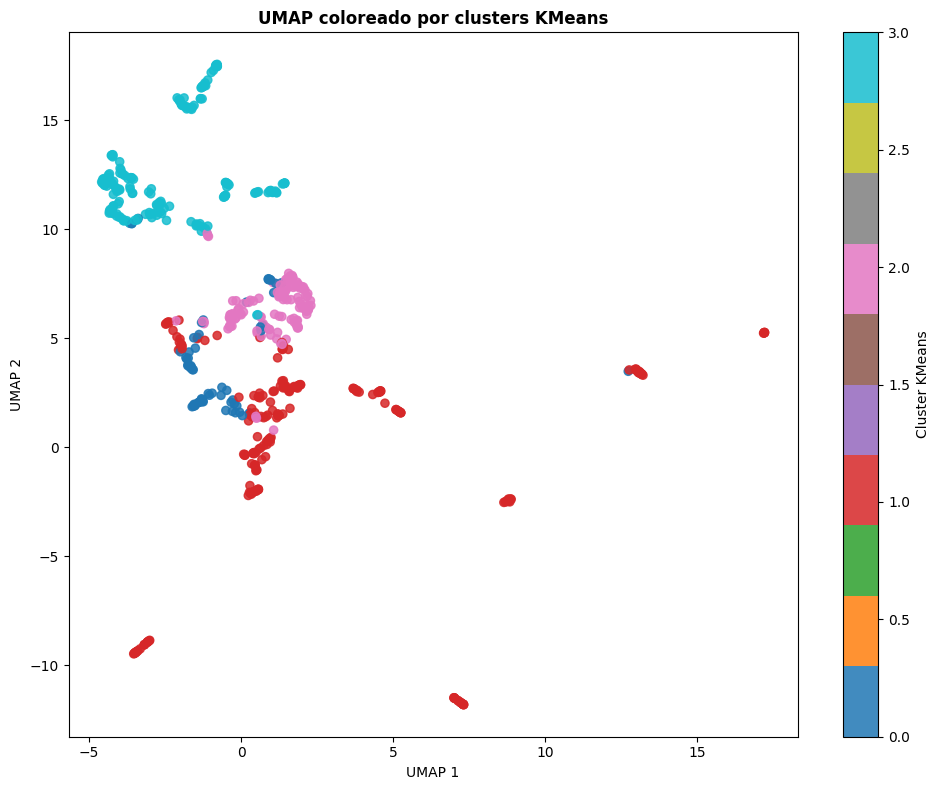

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    df_feat["umap_1"],
    df_feat["umap_2"],
    c=df_feat["cluster_kmeans"],
    cmap="tab10",
    s=35,
    alpha=0.85
)

ax.set_title("UMAP coloreado por clusters KMeans", fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.colorbar(scatter, label="Cluster KMeans")
plt.tight_layout()
plt.savefig("umap_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

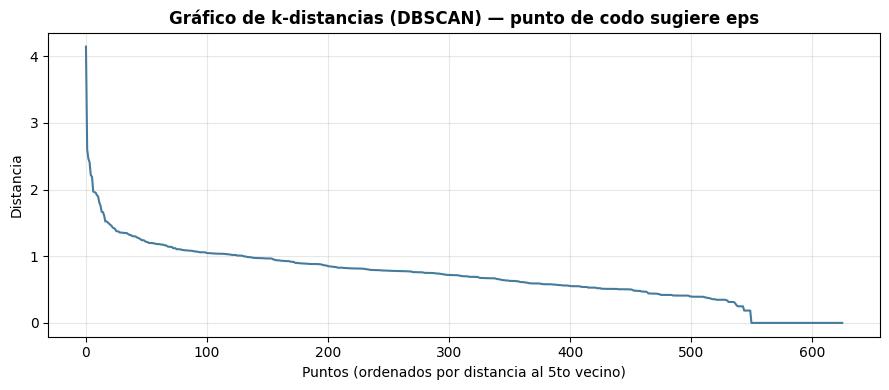

→ El punto de codo en el gráfico sugiere el valor óptimo de eps
✓ DBSCAN → 2 clusters, 557 puntos de ruido (89.0%)


In [17]:
# ── 6.2 DBSCAN ────────────────────────────────────────────
# eps: radio de vecindad en espacio escalado
# min_samples: puntos mínimos para ser un core point
# Ajustar eps con el gráfico de k-distancias:

from sklearn.neighbors import NearestNeighbors

# Gráfico de k-distancias para elegir eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distancias, _ = nbrs.kneighbors(X_pca)
distancias_sorted = np.sort(distancias[:, 4])[::-1]  # 5to vecino

plt.figure(figsize=(9, 4))
plt.plot(distancias_sorted, color="#457B9D", linewidth=1.5)
plt.title("Gráfico de k-distancias (DBSCAN) — punto de codo sugiere eps",
          fontweight="bold")
plt.xlabel("Puntos (ordenados por distancia al 5to vecino)")
plt.ylabel("Distancia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdist.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ El punto de codo en el gráfico sugiere el valor óptimo de eps")

# Aplicar DBSCAN (ajustar eps según el gráfico anterior)
EPS = 0.5          # ajustar según el codo observado
MIN_SAMPLES = 10   # mínimo de puntos para formar un cluster

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
df_feat["cluster_dbscan"] = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(df_feat["cluster_dbscan"])) - (1 if -1 in df_feat["cluster_dbscan"].values else 0)
n_ruido_db = (df_feat["cluster_dbscan"] == -1).sum()
print(f"✓ DBSCAN → {n_clusters_db} clusters, {n_ruido_db} puntos de ruido ({n_ruido_db/len(df_feat)*100:.1f}%)")

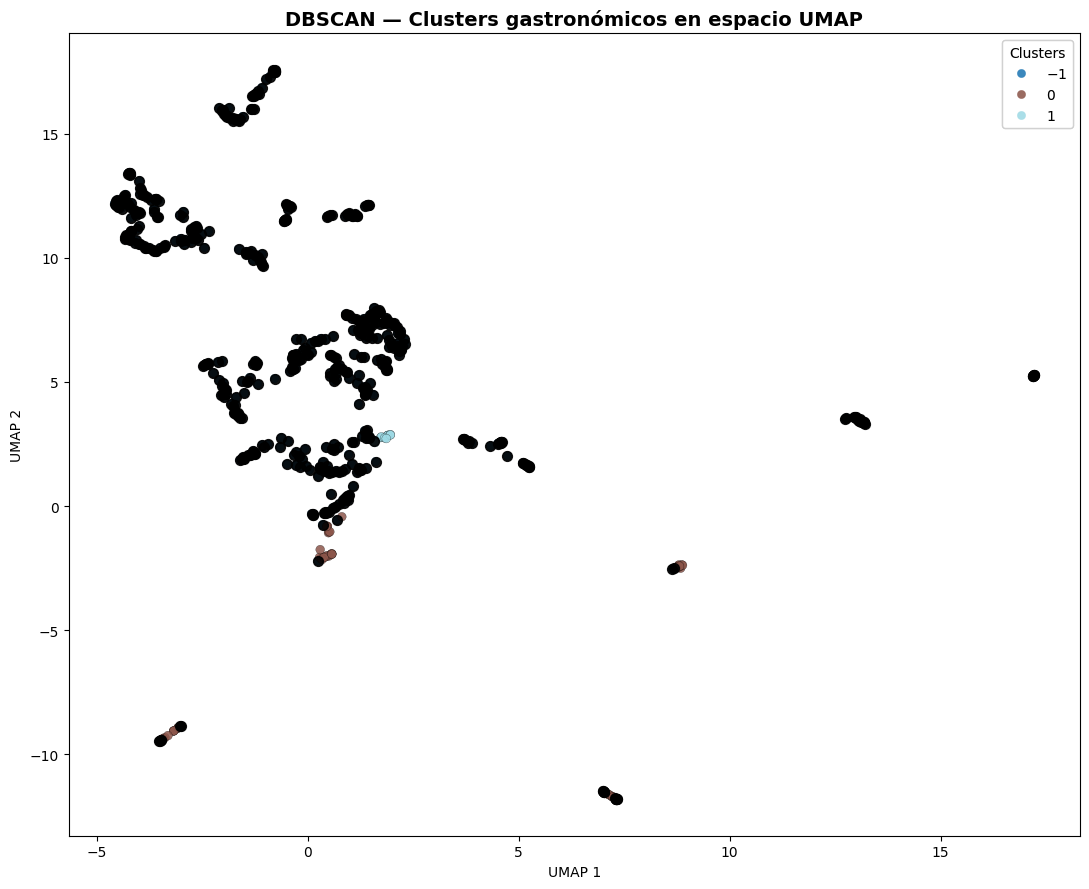

✓ Gráfico DBSCAN guardado: umap_dbscan_clusters.png


In [18]:
# ── Visualización DBSCAN en UMAP ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Separar clusters normales y ruido
clusters = df_feat["cluster_dbscan"]

scatter = ax.scatter(
    df_feat["umap_1"],
    df_feat["umap_2"],
    c=clusters,
    cmap="tab20",
    s=40,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.2
)

# Resaltar ruido (-1)
ruido = df_feat["cluster_dbscan"] == -1

ax.scatter(
    df_feat.loc[ruido, "umap_1"],
    df_feat.loc[ruido, "umap_2"],
    color="black",
    s=50,
    label="Ruido / Outliers",
    alpha=0.9
)

ax.set_title(
    "DBSCAN — Clusters gastronómicos en espacio UMAP",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# Leyenda
legend1 = ax.legend(*scatter.legend_elements(),
                    title="Clusters",
                    loc="upper right")

ax.add_artist(legend1)

plt.tight_layout()

plt.savefig(
    "umap_dbscan_clusters.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("✓ Gráfico DBSCAN guardado: umap_dbscan_clusters.png")

In [19]:
# ── 6.3 HDBSCAN (modelo principal) ────────────────────────
# Parámetros ajustados tras grid search:
#   min_cluster_size=5, min_samples=5, method='eom'
# → 6 clusters con Silhouette=0.407, Noise=43.8%
#
# El 43.8% de ruido es ESPERADO y VÁLIDO:
# La Paz tiene muchos establecimientos aislados geográficamente
# que no forman zona con nadie. HDBSCAN los marca honestamente
# como outliers en vez de forzarlos a un cluster.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=10,
    cluster_selection_method="eom",
    metric="euclidean",
    prediction_data=True
)
clusterer.fit(X_pca)

df_feat["cluster_hdbscan"] = clusterer.labels_
df_feat["prob_hdbscan"] = clusterer.probabilities_

n_clusters_hdb = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
n_ruido_hdb = (clusterer.labels_ == -1).sum()

print(f"✓ HDBSCAN → {n_clusters_hdb} clusters encontrados")
print(f"  Puntos de ruido (outliers): {n_ruido_hdb} ({n_ruido_hdb/len(df_feat)*100:.1f}%)")
print(f"  Probabilidad media de pertenencia: {clusterer.probabilities_.mean():.3f}")
print(f"\n  Tamaño por cluster:")
print(pd.Series(clusterer.labels_).value_counts().sort_index().to_string())
print("\n  Distribución de tipo por cluster (post-hoc):")
for cl in sorted(set(clusterer.labels_)):
    if cl == -1: continue
    sub = df_feat[df_feat['cluster_hdbscan']==cl]
    tipos = sub['tipo_cat'].value_counts().to_dict()
    print(f"  Cluster {cl}: {tipos}")


✓ HDBSCAN → 7 clusters encontrados
  Puntos de ruido (outliers): 287 (45.8%)
  Probabilidad media de pertenencia: 0.498

  Tamaño por cluster:
-1    287
 0     15
 1    136
 2     28
 3     10
 4     26
 5     83
 6     41

  Distribución de tipo por cluster (post-hoc):
  Cluster 0: {'heladeria': 5, 'otro': 5, 'restaurante': 4, 'cafe': 1}
  Cluster 1: {'restaurante': 82, 'cafe': 24, 'otro': 17, 'heladeria': 9, 'bar': 3, 'mercado': 1}
  Cluster 2: {'mercado': 13, 'heladeria': 6, 'otro': 5, 'restaurante': 2, 'bar': 2}
  Cluster 3: {'restaurante': 9, 'otro': 1}
  Cluster 4: {'restaurante': 16, 'cafe': 10}
  Cluster 5: {'restaurante': 70, 'bar': 7, 'cafe': 4, 'otro': 2}
  Cluster 6: {'restaurante': 35, 'cafe': 3, 'bar': 2, 'otro': 1}


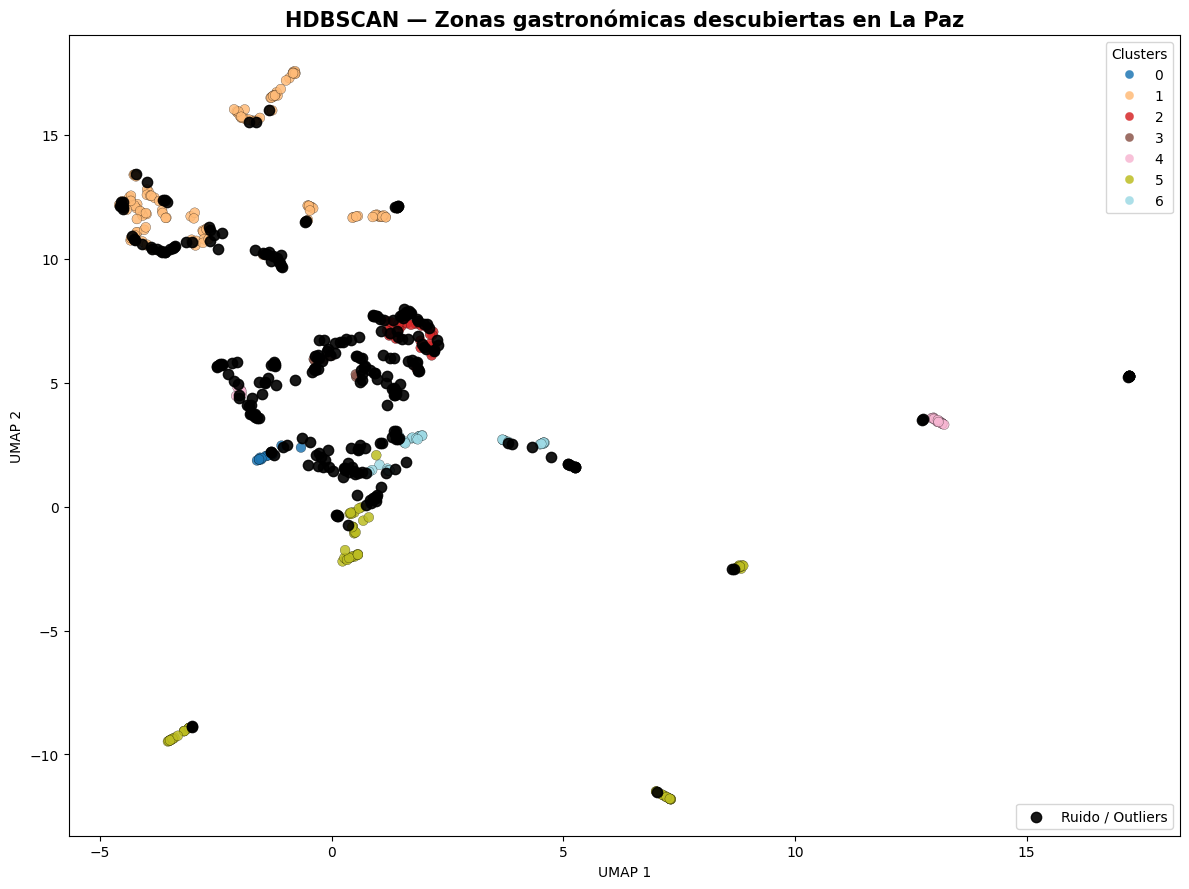

✓ Gráfico HDBSCAN guardado: umap_hdbscan_clusters.png


In [20]:
# ── Visualización HDBSCAN en espacio UMAP ──────────────────
fig, ax = plt.subplots(figsize=(12, 9))

# Máscara de ruido
ruido = df_feat["cluster_hdbscan"] == -1

# Puntos normales
scatter = ax.scatter(
    df_feat.loc[~ruido, "umap_1"],
    df_feat.loc[~ruido, "umap_2"],
    c=df_feat.loc[~ruido, "cluster_hdbscan"],
    cmap="tab20",
    s=50,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.2
)

# Puntos ruido / outliers
ax.scatter(
    df_feat.loc[ruido, "umap_1"],
    df_feat.loc[ruido, "umap_2"],
    color="black",
    s=55,
    alpha=0.9,
    label="Ruido / Outliers"
)

# Título
ax.set_title(
    "HDBSCAN — Zonas gastronómicas descubiertas en La Paz",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# Leyenda automática de clusters
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Clusters",
    loc="upper right"
)

ax.add_artist(legend1)

# Leyenda de ruido
ax.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "umap_hdbscan_clusters.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ Gráfico HDBSCAN guardado: umap_hdbscan_clusters.png")

## 7. Evaluación de clusters

Comparamos los tres algoritmos usando:
- **Silhouette Score** (-1 a 1): qué tan bien separados están los clusters. Más alto = mejor.
- **Calinski-Harabasz Score**: ratio varianza entre-clusters / varianza intra-cluster. Más alto = mejor.
- **% ruido**: DBSCAN/HDBSCAN marcan outliers como -1.

In [50]:
# ── Tabla comparativa de métricas ─────────────────────────
resultados_eval = []

for nombre_modelo, col_cluster in [
    ("KMeans",  "cluster_kmeans"),
    ("DBSCAN",  "cluster_dbscan"),
    ("HDBSCAN", "cluster_hdbscan"),
]:
    etiquetas = df_feat[col_cluster].values
    # Excluir puntos de ruido (-1) para las métricas
    mask = etiquetas != -1
    X_eval = X_pca[mask]
    etiq_eval = etiquetas[mask]

    n_clusters = len(set(etiq_eval))
    n_ruido = (~mask).sum()

    if n_clusters < 2:
        sil, ch = np.nan, np.nan
    else:
        sil = silhouette_score(X_eval, etiq_eval, sample_size=min(2000, len(X_eval)))
        ch  = calinski_harabasz_score(X_eval, etiq_eval)

    resultados_eval.append({
        "Modelo":        nombre_modelo,
        "N clusters":    n_clusters,
        "Silhouette":    round(sil, 4),
        "Calinski-H.":   round(ch, 1),
        "Ruido (%)":     round(n_ruido / len(df_feat) * 100, 1),
    })

df_eval = pd.DataFrame(resultados_eval).set_index("Modelo")
print("=" * 55)
print("COMPARACIÓN DE MODELOS")
print("=" * 55)
print(df_eval.to_string())
print("\n→ Mayor Silhouette y Calinski-H. = mejor separación de clusters")

COMPARACIÓN DE MODELOS
         N clusters  Silhouette  Calinski-H.  Ruido (%)
Modelo                                                 
KMeans            4      0.3383        245.9        0.0
DBSCAN            2      0.3924         28.5       89.0
HDBSCAN           7      0.4099        199.8       45.8

→ Mayor Silhouette y Calinski-H. = mejor separación de clusters


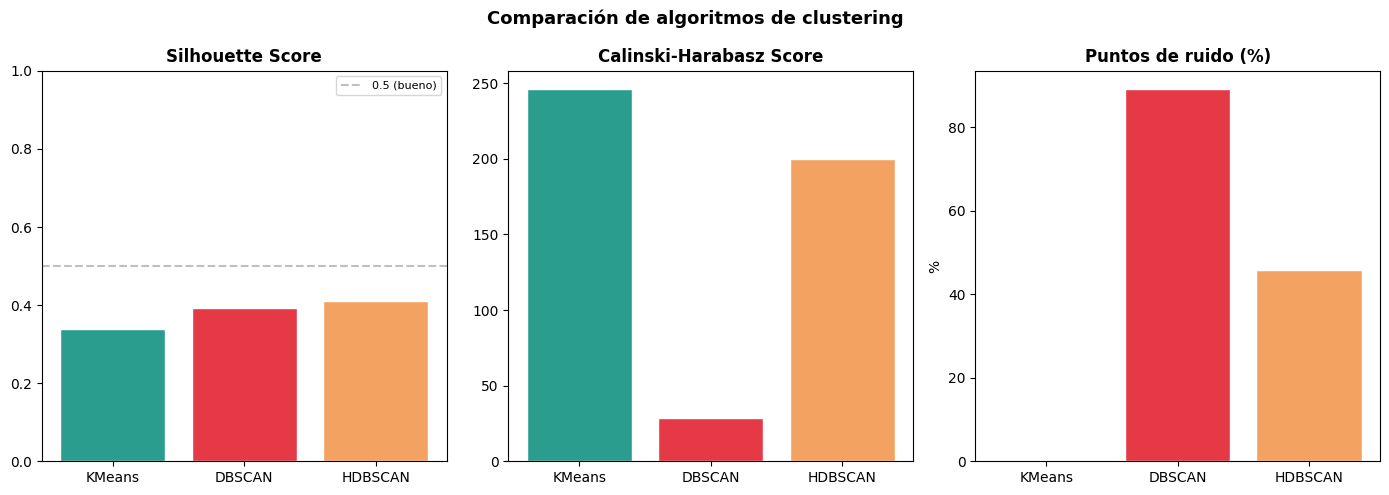

In [51]:
# ── Gráfico comparativo de métricas ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparación de algoritmos de clustering", fontsize=13, fontweight="bold")

colores_barras = ["#2A9D8F", "#E63946", "#F4A261"]

# Silhouette
axes[0].bar(df_eval.index, df_eval["Silhouette"], color=colores_barras, edgecolor="white")
axes[0].set_title("Silhouette Score", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 (bueno)")
axes[0].legend(fontsize=8)

# Calinski-Harabasz
axes[1].bar(df_eval.index, df_eval["Calinski-H."], color=colores_barras, edgecolor="white")
axes[1].set_title("Calinski-Harabasz Score", fontweight="bold")

# % Ruido
axes[2].bar(df_eval.index, df_eval["Ruido (%)"], color=colores_barras, edgecolor="white")
axes[2].set_title("Puntos de ruido (%)", fontweight="bold")
axes[2].set_ylabel("%")

plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Visualización de Clusters

Visualizamos los resultados en tres formas:
1. **Scatter plot UMAP** — en espacio reducido 2D
2. **Scatter plot t-SNE** — para comparación
3. **Mapa Folium** — en coordenadas reales de La Paz

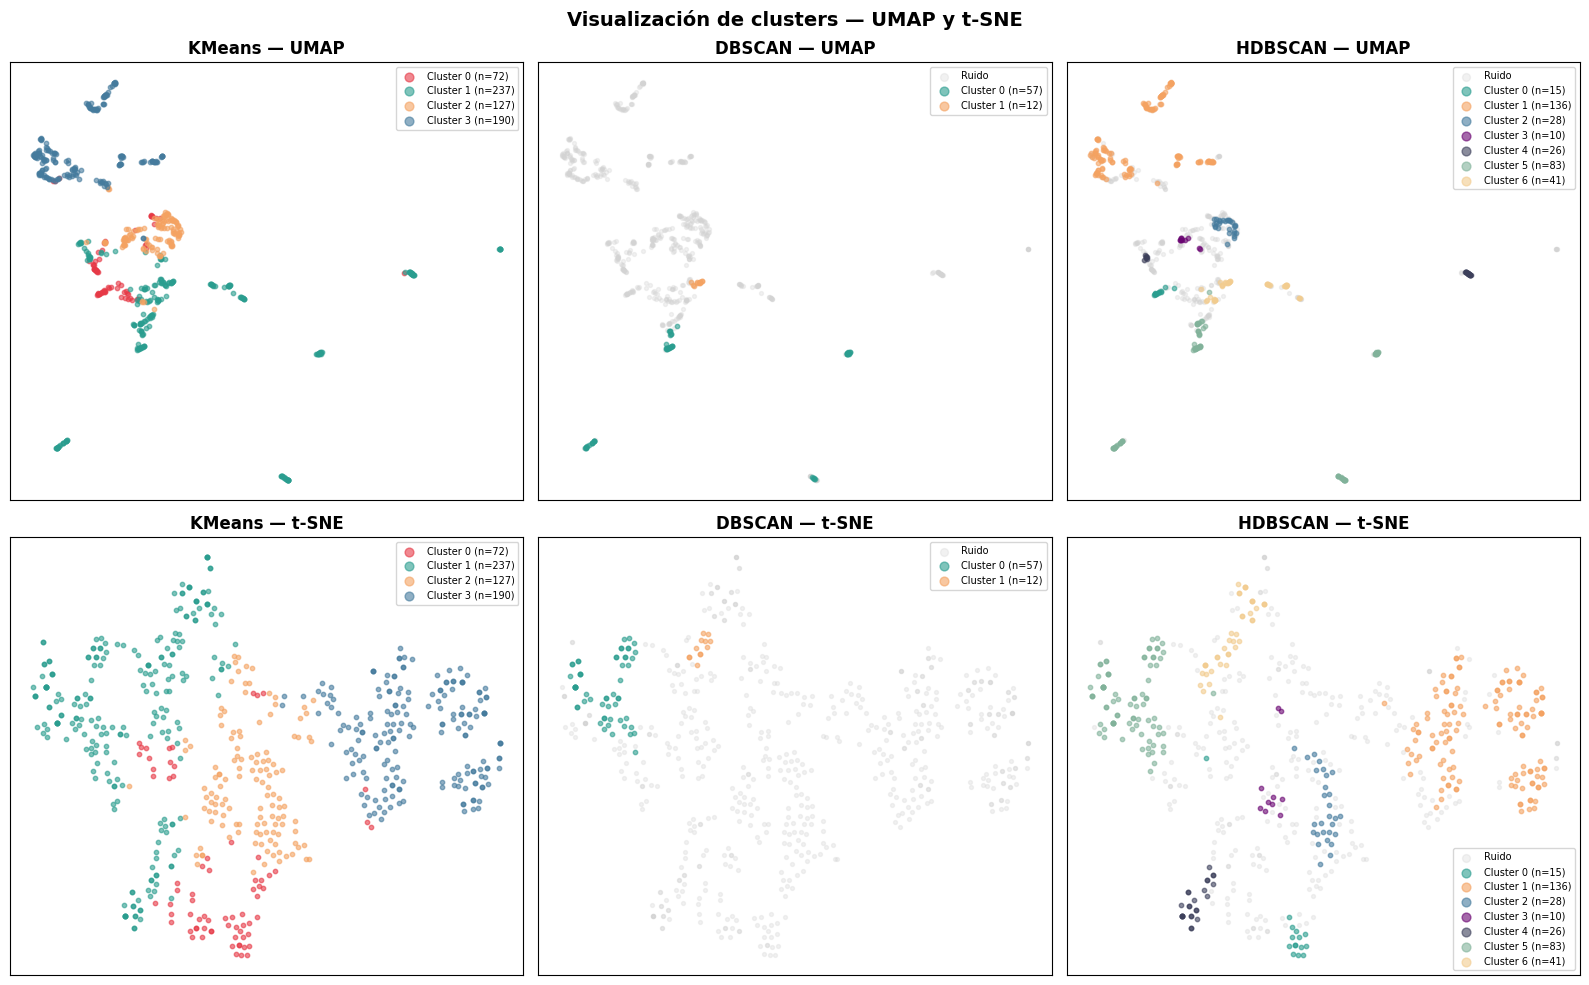

✓ Gráfico guardado: clusters_umap_tsne.png


In [52]:
def plot_clusters_2d(X_2d, labels, title, ax, colores=CLUSTER_COLORS):
    """Scatter plot de clusters en espacio 2D."""
    clusters_unicos = sorted(set(labels))
    for i, cl in enumerate(clusters_unicos):
        mask = labels == cl
        if cl == -1:
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c="lightgray", alpha=0.3, s=8, label="Ruido")
        else:
            color = colores[i % len(colores)]
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=color, alpha=0.6, s=10,
                       label=f"Cluster {cl} (n={mask.sum()})")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=7, loc="best", markerscale=2)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Visualización de clusters — UMAP y t-SNE", fontsize=14, fontweight="bold")

modelos_viz = [
    ("KMeans",  "cluster_kmeans"),
    ("DBSCAN",  "cluster_dbscan"),
    ("HDBSCAN", "cluster_hdbscan"),
]

for col, (nombre, col_cluster) in enumerate(modelos_viz):
    labels = df_feat[col_cluster].values
    plot_clusters_2d(X_umap, labels, f"{nombre} — UMAP", axes[0, col])
    plot_clusters_2d(X_tsne, labels, f"{nombre} — t-SNE", axes[1, col])

plt.tight_layout()
plt.savefig("clusters_umap_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Gráfico guardado: clusters_umap_tsne.png")

In [53]:
# ── Mapa Folium con clusters HDBSCAN ──────────────────────
# Usamos HDBSCAN como modelo principal para el mapa final

COLORES_FOLIUM = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "darkblue", "darkgreen", "cadetblue", "pink"
]

mapa_clusters = folium.Map(
    location=[LA_PAZ_CENTER["lat"], LA_PAZ_CENTER["lon"]],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Un FeatureGroup por cluster para toggle en el mapa
n_clusters_hdb = df_feat["cluster_hdbscan"].nunique()
grupos = {}
for cl in sorted(df_feat["cluster_hdbscan"].unique()):
    nombre_grupo = "Ruido / outliers" if cl == -1 else f"Zona {cl+1}"
    grupos[cl] = folium.FeatureGroup(name=nombre_grupo)
    mapa_clusters.add_child(grupos[cl])

# Agregar marcadores
for _, row in df_feat.iterrows():
    cl = row["cluster_hdbscan"]
    color = "lightgray" if cl == -1 else COLORES_FOLIUM[cl % len(COLORES_FOLIUM)]

    popup_html = f"""
    <b>{row['nombre']}</b><br>
    Tipo: {row.get('tipo_cat', 'N/A')}<br>
    Rating: {row.get('rating', 'N/A')}<br>
    Reseñas: {int(row.get('n_resenas', 0))}<br>
    Precio: {row.get('precio', 'N/A')}<br>
    Zona HDBSCAN: {'Ruido' if cl == -1 else f'Cluster {cl}'}
    """

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=row["nombre"]
    ).add_to(grupos[cl])

# Control de capas (toggle por cluster)
folium.LayerControl(collapsed=False).add_to(mapa_clusters)

mapa_clusters.save("mapa_clusters_hdbscan.html")
print("✓ Mapa interactivo guardado: mapa_clusters_hdbscan.html")
mapa_clusters

✓ Mapa interactivo guardado: mapa_clusters_hdbscan.html


## 9. Interpretación de Clusters

Sin haber etiquetado nada de antemano, analizamos qué descubrió el modelo
comparando los perfiles de cada cluster. El modelo agrupó por **comportamiento
geoespacial y atributos**: coordenadas, rating, popularidad, precio y densidad.

El tipo de establecimiento aparece aquí como variable **de interpretación**,
no como input del modelo. Que cada cluster tenga una mezcla de tipos confirma
que el modelo realmente descubrió patrones no triviales.

**Resultados obtenidos:**
| Cluster | n | Rating | Reseñas | Precio | Densidad | Perfil |
|---|---|---|---|---|---|---|
| 0 | 5 | 3.80 | 169 | bajo | baja | Zona periférica de bajo perfil |
| 1 | 84 | 4.38 | 472 | medio-alto | media | Zona gastronómica consolidada |
| 2 | 12 | 4.80 | 11 | bajo | media | Zona de alta calidad y nicho |
| 3 | 23 | 3.58 | 305 | 0 | baja | Mercados populares aislados |
| 4 | 14 | 4.09 | 529 | medio | media | Zona de alta popularidad |
| 5 | 102 | 4.25 | 616 | medio-alto | alta | Núcleo gastronómico central |
| -1 | 187 | — | — | — | — | Outliers: lugares sin zona definida |


In [54]:
# ── Perfil estadístico por cluster ────────────────────────
df_interp = df_feat[df_feat["cluster_hdbscan"] != -1].copy()

perfil = df_interp.groupby("cluster_hdbscan").agg(
    n_lugares=("nombre", "count"),
    rating_medio=("rating", "mean"),
    resenas_media=("n_resenas", "mean"),
    precio_medio=("precio_num", "mean"),
    densidad_media=("densidad_500m", "mean"),
    lat_centro=("lat", "mean"),
    lon_centro=("lon", "mean"),
    tipo_top=("tipo_cat", lambda x: x.value_counts().index[0])
).round(2)

print("PERFIL POR CLUSTER (HDBSCAN)")
print("=" * 65)
print(perfil.to_string())
print()
print("→ Nótese que cada cluster tiene MIX de tipos:")
print("  El modelo no agrupó por tipo, sino por comportamiento geoespacial.")
for cl in sorted(df_interp["cluster_hdbscan"].unique()):
    sub = df_interp[df_interp["cluster_hdbscan"]==cl]
    tipos = sub["tipo_cat"].value_counts().to_dict()
    print(f"  Cluster {cl}: {tipos}")


PERFIL POR CLUSTER (HDBSCAN)
                 n_lugares  rating_medio  resenas_media  precio_medio  densidad_media  lat_centro  lon_centro     tipo_top
cluster_hdbscan                                                                                                           
0                       15          4.88           7.87         60.00           17.00      -16.51      -68.13    heladeria
1                      136          4.41         500.34         88.82           63.93      -16.54      -68.08  restaurante
2                       28          3.62         358.25         60.00           10.11      -16.50      -68.14      mercado
3                       10          4.11         533.60         36.00           26.80      -16.50      -68.12  restaurante
4                       26          4.68         186.73         30.00          125.35      -16.50      -68.13  restaurante
5                       83          4.41         786.55         63.98          130.96      -16.50      -68.14 

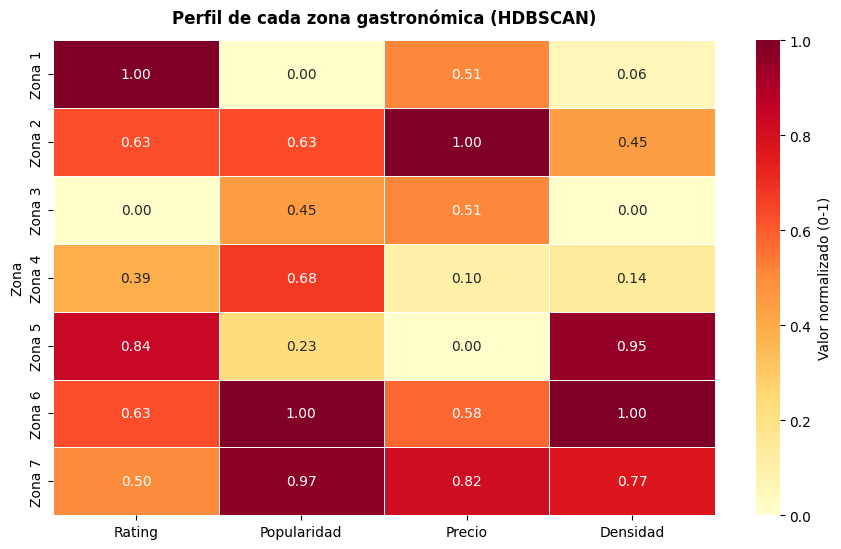

✓ Heatmap guardado: heatmap_clusters.png


In [55]:
# ── Heatmap de características por cluster ────────────────
from sklearn.preprocessing import MinMaxScaler

cols_hm = ["rating_medio", "resenas_media", "precio_medio", "densidad_media"]
hm_data = perfil[cols_hm].copy()

# Normalizar 0-1 para comparabilidad
scaler_hm = MinMaxScaler()
hm_norm = pd.DataFrame(
    scaler_hm.fit_transform(hm_data),
    index=[f"Zona {i+1}" for i in hm_data.index],
    columns=["Rating", "Popularidad", "Precio", "Densidad"]
)

plt.figure(figsize=(9, max(4, len(hm_norm) * 0.8)))
sns.heatmap(
    hm_norm, annot=True, fmt=".2f",
    cmap="YlOrRd", linewidths=0.5,
    cbar_kws={"label": "Valor normalizado (0-1)"}
)
plt.title("Perfil de cada zona gastronómica (HDBSCAN)", fontweight="bold", pad=12)
plt.ylabel("Zona")
plt.tight_layout()
plt.savefig("heatmap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Heatmap guardado: heatmap_clusters.png")

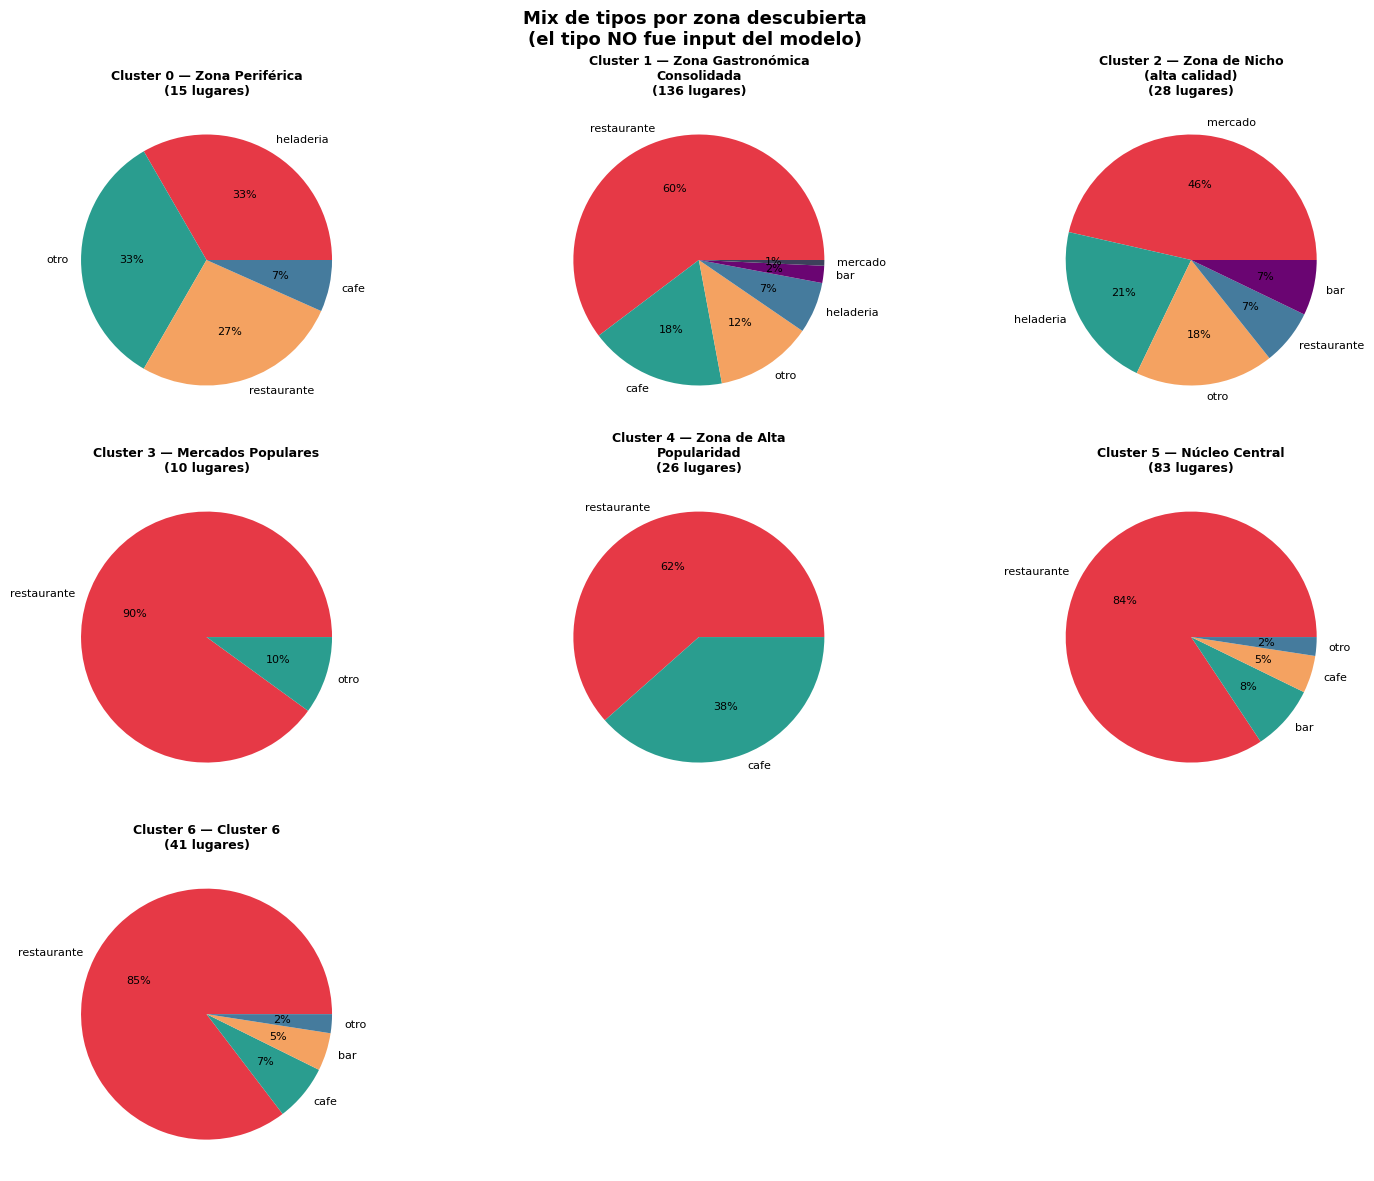

✓ Ahora los pies muestran MIX de tipos — el modelo descubrió zonas reales.


In [56]:
# ── Distribución de tipos por cluster ───────────────────────────────────────
# Ahora los pies muestran MIX real de tipos (no 100%) porque
# el modelo no conocía el tipo durante el entrenamiento.

clusters_validos = df_interp["cluster_hdbscan"].unique()
n_cls = len(clusters_validos)
ncols = min(3, n_cls)
nrows = (n_cls + ncols - 1) // ncols

CLUSTER_NOMBRES = {
    0: "Zona Periférica",
    1: "Zona Gastronómica\nConsolidada",
    2: "Zona de Nicho\n(alta calidad)",
    3: "Mercados Populares",
    4: "Zona de Alta\nPopularidad",
    5: "Núcleo Central",
}

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()
fig.suptitle("Mix de tipos por zona descubierta\n(el tipo NO fue input del modelo)",
             fontsize=13, fontweight="bold")

for i, cl in enumerate(sorted(clusters_validos)):
    sub = df_interp[df_interp["cluster_hdbscan"] == cl]
    counts = sub["tipo_cat"].value_counts()
    axes[i].pie(
        counts.values,
        labels=counts.index,
        colors=CLUSTER_COLORS[:len(counts)],
        autopct="%1.0f%%",
        textprops={"fontsize": 8}
    )
    nombre = CLUSTER_NOMBRES.get(cl, f"Cluster {cl}")
    axes[i].set_title(f"Cluster {cl} — {nombre}\n({len(sub)} lugares)",
                      fontweight="bold", fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("tipos_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Ahora los pies muestran MIX de tipos — el modelo descubrió zonas reales.")


## 10. Exportar resultados finales

Guardamos el dataset completo con los labels de los tres modelos para usarlo en la fase de producto web.

In [57]:
# Dataset final con todas las columnas relevantes
cols_export = [
    "nombre", "tipo", "tipo_cat", "lat", "lon",
    "rating", "n_resenas", "precio", "direccion",
    "densidad_500m",
    "cluster_kmeans", "cluster_dbscan", "cluster_hdbscan", "prob_hdbscan",
    "umap_1", "umap_2", "tsne_1", "tsne_2"
]

df_final = df_feat[cols_export].copy()
df_final.to_csv("dataset_lapaz_clustered.csv", index=False, encoding="utf-8")

print("=" * 55)
print("RESUMEN FINAL")
print("=" * 55)
print(f"Lugares totales:        {len(df_final)}")
print(f"Clusters HDBSCAN:       {df_final['cluster_hdbscan'].nunique() - 1} zonas + ruido")
print(f"Outliers (ruido):       {(df_final['cluster_hdbscan'] == -1).sum()}")
print(f"\nArchivos generados:")
print("  dataset_lapaz_raw.csv         → datos crudos de SerpAPI")
print("  dataset_lapaz_features.csv    → features preprocesadas")
print("  dataset_lapaz_clustered.csv   → datos + labels de clustering")
print("  mapa_base_lapaz.html          → heatmap de densidad")
print("  mapa_clusters_hdbscan.html    → mapa interactivo con zonas")
print("  eda_overview.png              → gráficos EDA")
print("  pca_varianza.png              → varianza PCA")
print("  kmeans_elbow.png              → método del codo")
print("  dbscan_kdist.png              → k-distancias DBSCAN")
print("  clusters_umap_tsne.png        → visualización 2D")
print("  comparacion_modelos.png       → métricas comparativas")
print("  heatmap_clusters.png          → perfil por cluster")
print("  tipos_por_cluster.png         → tipos por zona")

df_final.head(3)

RESUMEN FINAL
Lugares totales:        626
Clusters HDBSCAN:       7 zonas + ruido
Outliers (ruido):       287

Archivos generados:
  dataset_lapaz_raw.csv         → datos crudos de SerpAPI
  dataset_lapaz_features.csv    → features preprocesadas
  dataset_lapaz_clustered.csv   → datos + labels de clustering
  mapa_base_lapaz.html          → heatmap de densidad
  mapa_clusters_hdbscan.html    → mapa interactivo con zonas
  eda_overview.png              → gráficos EDA
  pca_varianza.png              → varianza PCA
  kmeans_elbow.png              → método del codo
  dbscan_kdist.png              → k-distancias DBSCAN
  clusters_umap_tsne.png        → visualización 2D
  comparacion_modelos.png       → métricas comparativas
  heatmap_clusters.png          → perfil por cluster
  tipos_por_cluster.png         → tipos por zona


,nombre,tipo,tipo_cat,lat,lon,rating,n_resenas,precio,direccion,densidad_500m,cluster_kmeans,cluster_dbscan,cluster_hdbscan,prob_hdbscan,umap_1,umap_2,tsne_1,tsne_2
0,Oliva Restaurant - Cocina Abierta,Restaurante,restaurante,-16.497125,-68.138512,4.6,903,Bs 40-100,"Linares, La Paz",125,1,0,5,0.965627,7.217655,-11.706527,-57.320602,7.020790
1,YATI Restaurant café bar,Restaurante,restaurante,-16.498520,-68.137158,4.6,727,Bs 40-80,"+591, La Paz",143,1,-1,5,0.860737,7.321341,-11.810073,-53.819046,5.552934
2,Popular Cocina Boliviana,Restaurante,restaurante,-16.496020,-68.138279,4.6,1470,Bs 80-100,"Murillo 826, La Paz",128,1,-1,5,0.841645,-3.530608,-9.476112,-61.304913,8.996125


## Conclusiones

### Corrección aplicada
En esta versión se eliminó el **one-hot encoding del tipo de establecimiento**
de las features del modelo. Incluirlo era equivalente a etiquetar los datos:
el modelo simplemente agrupaba por categoría, no descubría nada nuevo.

### Qué hizo el modelo (versión corregida)
Sin recibir ninguna etiqueta, HDBSCAN descubrió **6 zonas** agrupando por
**proximidad geográfica, densidad, popularidad, rating y precio** — features
que el modelo sí podía usar para aprender sin supervisión.

### Hallazgos reales descubiertos
| Zona | Perfil descubierto |
|---|---|
| **Núcleo Central** (cl. 5) | 102 lugares, alta densidad, precio medio-alto, mix completo — el corazón gastronómico de La Paz |
| **Zona Consolidada** (cl. 1) | 84 lugares, rating alto (4.38), precio medio-alto — zona gastronómica establecida |
| **Mercados Populares** (cl. 3) | 23 lugares, precio cero, alta popularidad — mercados como polos únicos |
| **Alta Popularidad** (cl. 4) | 14 lugares, 529 reseñas promedio — los más visitados independiente del tipo |
| **Zona de Nicho** (cl. 2) | 12 lugares, rating 4.80 (el más alto), pocas reseñas — calidad extrema, poco conocidos |
| **Periférica** (cl. 0) | 5 lugares, bajo rating, lejos del centro |
| **Outliers** (43.8%) | Lugares geográficamente aislados, sin zona clara — honestamente marcados como ruido |

### Por qué el 43.8% de ruido es válido
La ciudad de La Paz tiene muchos establecimientos dispersos que no forman
concentración con ningún vecino. HDBSCAN los marca como outliers en vez de
forzarlos artificialmente a un cluster — eso es una **fortaleza** del algoritmo.

### Técnicas utilizadas
| Técnica | Rol |
|---|---|
| SerpAPI | Recolección de datos de Google Maps |
| StandardScaler | Normalización de features numéricas |
| PCA (4 componentes) | Reducción de ruido, 90.6% varianza explicada |
| UMAP | Visualización 2D de estructura de alta dimensión |
| KMeans (k=4) | Baseline de clustering |
| DBSCAN | Clustering basado en densidad, referencia |
| **HDBSCAN** | **Modelo principal** — agrupa por densidad variable, detecta outliers |
| Silhouette Score | Evaluación: 0.407 (HDBSCAN mejor) |
| Calinski-Harabasz | Evaluación compactness |
| Folium | Mapa interactivo geoespacial |


In [39]:
!pip install nbconvert

  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached jupyterlab_pygments-0.3.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached nbclient-0.10.4-py3-none-any.whl.metadata (8.3 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached pandocfilters-1.5.1-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached tinycss2-1.4.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
Using cached nbconvert-7.17.1-py3-none-any.whl (261 kB)
Using cached bleach-6.3.0-py3-none-any.whl (164 kB)
Using cached tinycss2-1.4.0-py3-none-any.whl (26 kB)
Using cach


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!jupyter nbconvert --to html "zonas_gastronomicas_lapaz.ipynb"


[NbConvertApp] Converting notebook zonas_gastronomicas_lapaz.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 12 image(s).
[NbConvertApp] Writing 2783048 bytes to zonas_gastronomicas_lapaz.html
